<a href="https://colab.research.google.com/github/Notmefrfr/Notmefrfr/blob/latihan/latihanbdp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [139]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import pandas as pd

In [140]:
spark = SparkSession.builder.getOrCreate()

msBrand = spark.read.option("inferSchema","true").csv("MsBrand.csv",header=True)
msCountry = spark.read.option("inferSchema","true").csv("MsCountry.csv",header=True)
msCustomer = spark.read.option("inferSchema","true").csv("MsCustomer.csv",header=True)
msRamen = spark.read.option("inferSchema","true").csv("MsRamen.csv",header=True)
msRamenStyle = spark.read.option("inferSchema","true").csv("MsRamenStyle.csv",header = True)
transactionHeader = spark.read.option("inferSchema","true").csv("TransactionHeader.csv",header=True)
transactionDetail = spark.read.option("inferSchema","true").csv("TransactionDetail.csv",header=True)



msBrand.registerTempTable("MsBrand")
msCountry.registerTempTable("MsCountry")
msCustomer.registerTempTable("MsCustomer")
msRamen.registerTempTable("MsRamen")
msRamenStyle.registerTempTable("MsRamenStyle")
transactionHeader.registerTempTable("TransactionHeader")
transactionDetail.registerTempTable("TransactionDetail")


/usr/local/lib/python3.11/dist-packages/pyspark/sql/dataframe.py:329: FutureWarning: Deprecated in 2.0, use createOrReplaceTempView instead.
  warnings.warn("Deprecated in 2.0, use createOrReplaceTempView instead.", FutureWarning)


In [141]:
res1 = spark.sql("""
  SELECT COUNT(mr.RamenID) AS Ramencount, mc.CountryName
  FROM MsRamen mr
  JOIN MsCountry mc ON mr.CountryID = mc.CountryID
  GROUP BY mc.CountryName
  ORDER BY Ramencount DESC
  LIMIT 5
""")

res1.show()

+----------+-----------+
|Ramencount|CountryName|
+----------+-----------+
|       352|      Japan|
|       323|        USA|
|       309|South Korea|
|       224|     Taiwan|
|       191|   Thailand|
+----------+-----------+



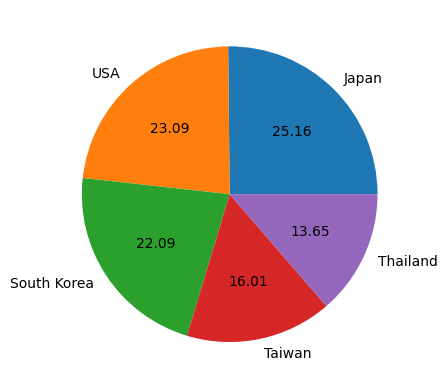

In [142]:
res1 = res1.toPandas()

plt.pie(res1["Ramencount"],labels=res1["CountryName"],autopct="%.2f")
plt.show()

In [143]:
res2 = spark.sql("""
  SELECT SUM(mr.RamenPrice * mt.Quantity) as TotalSales, MONTH(th.TransactionDate) as Month
  FROM MsRamen mr
  JOIN TransactionDetail mt ON mr.RamenID = mt.RamenID
  JOIN TransactionHeader th ON mt.TransactionID = th.TransactionID
  WHERE YEAR(th.TransactionDate) = 2019
  GROUP BY MONTH(TransactionDate)
  ORDER BY Month
""")

res2.show()

+----------+-----+
|TotalSales|Month|
+----------+-----+
| 316534000|    1|
| 292087000|    2|
| 328064000|    3|
| 302013000|    4|
| 305102000|    5|
| 310177000|    6|
| 312101000|    7|
| 328337000|    8|
| 307199000|    9|
| 317046000|   10|
| 317946000|   11|
| 295857000|   12|
+----------+-----+



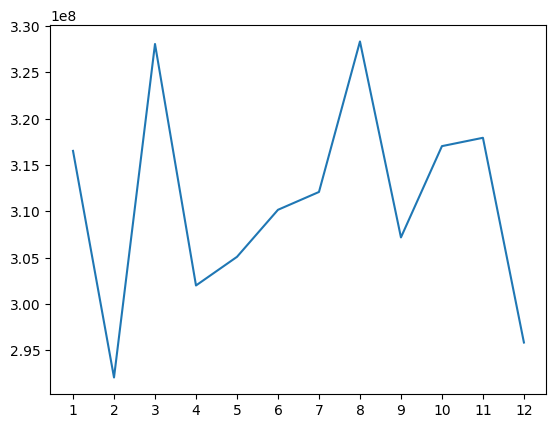

In [144]:
res2 = res2.toPandas()

plt.plot(res2["TotalSales"])
plt.xticks(range(len(res2["Month"])),res2["Month"])
plt.show()

In [145]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.ml.feature import VectorAssembler,StandardScaler
from pyspark.ml.clustering import KMeans
import matplotlib.pyplot as plt

In [146]:
spark = SparkSession.builder.getOrCreate()

df = spark.read.option("inferSchema","true").csv("Clustering.csv",header = "True")
df.show(5)

+---------------+-----------------+--------------+-------------------+--------+--------------+---------------+
|Trash Pollution|Oil Concentration|Bacteria Level|Algae Concentration|Humidity|Wind Direction|Air Temperature|
+---------------+-----------------+--------------+-------------------+--------+--------------+---------------+
|            Low|             2.22|           207|               6.05|      52|           280|             38|
|           High|             1.37|           133|               4.21|      60|            30|           NULL|
|         Medium|             0.65|            84|               8.07|      18|           164|             12|
|           NULL|             2.62|           276|               6.53|      93|           254|             29|
|            Low|             1.68|           126|               1.73|      52|           176|             18|
+---------------+-----------------+--------------+-------------------+--------+--------------+---------------+
o

In [147]:
df = df.select("Trash Pollution","Oil Concentration","Bacteria Level")

In [148]:
df = df.dropna()

In [149]:
df = df.withColumn("Trash Pollution",
                   when(df["Trash Pollution"]=="Low",0).
                   when(df["Trash Pollution"]=="Medium",1).
                   when(df["Trash Pollution"]=="High",2)
                   )

In [150]:
df = VectorAssembler(inputCols=df.columns,outputCol="vector").transform(df)
df = StandardScaler(inputCol="vector",outputCol="features").fit(df).transform(df)

In [164]:
model = KMeans().setK(2)
result = model.fit(df).transform(df)


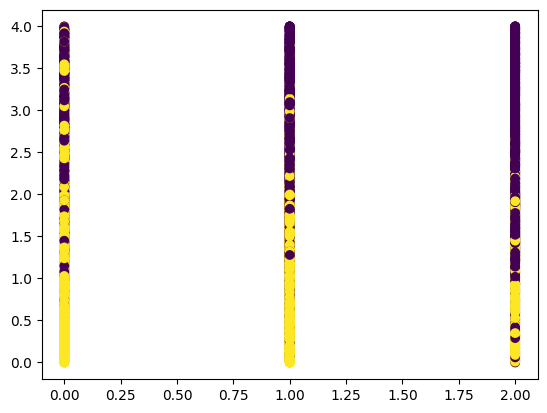

In [165]:
resultpanda = result.toPandas()

plt.scatter(resultpanda["Trash Pollution"],
            resultpanda["Oil Concentration"],
            c=resultpanda["prediction"])

plt.show()

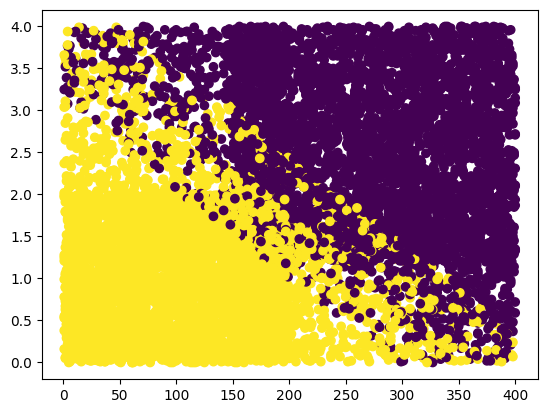

In [153]:
plt.scatter(resultpanda["Bacteria Level"], resultpanda["Oil Concentration"], c=resultpanda["prediction"])
plt.show()

In [154]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

spark = SparkSession.builder.getOrCreate()

In [155]:
df_train = spark.read.option("inferSchema","true").csv("Classification_Train.csv",header=True)
df_test = spark.read.option("inferSchema","true").csv("Classification_Test.csv",header=True)

df_train.show(3)
df_test.show(3)

+--------------+------+------+---------------+---------+-------+-------------+---------+
|          Name|Gender|Height|Education Level|Eye Color|Married|Salary Income|Depressed|
+--------------+------+------+---------------+---------+-------+-------------+---------+
| Sax Tesseyman|Female|   174|   Intermediate|     Blue|    Yes|     85000000|       No|
|   Niels Greet|  Male|   165|   Intermediate|    Black|     No|     14000000|       No|
|Minetta Santry|Female|   160|            Low|    Black|     No|    148000000|      Yes|
+--------------+------+------+---------------+---------+-------+-------------+---------+
only showing top 3 rows

+----------------+------+------+---------------+---------+-------+-------------+---------+
|            Name|Gender|Height|Education Level|Eye Color|Married|Salary Income|Depressed|
+----------------+------+------+---------------+---------+-------+-------------+---------+
|    Lila Bracher|  Male|   151|            Low|    Black|     No|     74000000

In [156]:
df_train = df_train.select("Salary Income", "Married", "Education Level", "Depressed")
df_test = df_test.select("Salary Income", "Married", "Education Level", "Depressed")

df_train.show()

+-------------+-------+---------------+---------+
|Salary Income|Married|Education Level|Depressed|
+-------------+-------+---------------+---------+
|     85000000|    Yes|   Intermediate|       No|
|     14000000|     No|   Intermediate|       No|
|    148000000|     No|            Low|      Yes|
|     50000000|     No|           High|      Yes|
|    101000000|    Yes|   Intermediate|       No|
|    145000000|    Yes|            Low|      Yes|
|     55000000|     No|   Intermediate|      Yes|
|     51000000|    Yes|   Intermediate|       No|
|     97000000|     No|           High|      Yes|
|     41000000|     No|            Low|      Yes|
|     27000000|    Yes|           High|       No|
|      3000000|    Yes|           High|       No|
|      9000000|     No|           High|      Yes|
|     12000000|     No|   Intermediate|      Yes|
|     81000000|    Yes|   Intermediate|       No|
|     53000000|     No|           High|      Yes|
|     10000000|     No|            Low|      Yes|


In [157]:
df_train = df_train.na.drop()
df_test = df_test.na.drop()

In [158]:
#train
df_train = df_train.withColumn("Education Level", when(df_train["Education Level"] == "Low", 0).
	when(df_train["Education Level"] == "Intermediate", 1).
	when(df_train["Education Level"] == "High", 2))

# df_train = df_train.withColumn("Married", when(df_train["Married"] == "Yes", 1).when(df_train["Married"] == "No", 0))
df_train = df_train.withColumn("Married", when(df_train["Married"] == "Yes", 1).otherwise(0))

df_train = df_train.withColumn("Depressed", when(df_train["Depressed"] == "Yes", 1).otherwise(0))

#test
df_test = df_test.withColumn("Education Level", when(df_test["Education Level"] == "Low", 0).
	when(df_test["Education Level"] == "Intermediate", 1).
	when(df_test["Education Level"] == "High", 2))

# df_train = df_train.withColumn("Married", when(df_train["Married"] == "Yes", 1).when(df_train["Married"] == "No", 0))
df_test = df_test.withColumn("Married", when(df_test["Married"] == "Yes", 1).otherwise(0))

df_test = df_test.withColumn("Depressed", when(df_test["Depressed"] == "Yes", 1).otherwise(0))

df_train.show(3)
df_test.show(3)

+-------------+-------+---------------+---------+
|Salary Income|Married|Education Level|Depressed|
+-------------+-------+---------------+---------+
|     85000000|      1|              1|        0|
|     14000000|      0|              1|        0|
|    148000000|      0|              0|        1|
+-------------+-------+---------------+---------+
only showing top 3 rows

+-------------+-------+---------------+---------+
|Salary Income|Married|Education Level|Depressed|
+-------------+-------+---------------+---------+
|     74000000|      0|              0|        1|
|     29000000|      1|              2|        0|
|    134000000|      1|              1|        0|
+-------------+-------+---------------+---------+
only showing top 3 rows



In [159]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

cols = df_train.columns
#tidak perlu normalize target label
cols.remove("Depressed")

vec_assembler = VectorAssembler(inputCols=cols, outputCol="Features")
#inputCols -> kolum yang mau di-transform
#outputCol -> nama untuk kolum baru yang akan dibuat
df_train = vec_assembler.transform(df_train)
df_test = vec_assembler.transform(df_test)

#fit scaler hanya ke training set
scaler = StandardScaler(inputCol="Features", outputCol="Scaled_Features") #nama kolom
scaler_model = scaler.fit(df_train)

#transform ke training dan testing data
df_train = scaler_model.transform(df_train)
df_test = scaler_model.transform(df_test)

df_train.show(5)

+-------------+-------+---------------+---------+----------------+--------------------+
|Salary Income|Married|Education Level|Depressed|        Features|     Scaled_Features|
+-------------+-------+---------------+---------+----------------+--------------------+
|     85000000|      1|              1|        0| [8.5E7,1.0,1.0]|[2.05201112678426...|
|     14000000|      0|              1|        0| [1.4E7,0.0,1.0]|[0.33797830323505...|
|    148000000|      0|              0|        1|[1.48E8,0.0,0.0]|[3.57291349134201...|
|     50000000|      0|              2|        1| [5.0E7,0.0,2.0]|[1.20706536869662...|
|    101000000|      1|              1|        0|[1.01E8,1.0,1.0]|[2.43827204476718...|
+-------------+-------+---------------+---------+----------------+--------------------+
only showing top 5 rows



In [160]:
from pyspark.ml.classification import LogisticRegression

model = LogisticRegression(featuresCol="Scaled_Features", labelCol="Depressed", maxIter=10).fit(df_train)

In [161]:
prediction = model.transform(df_test)
prediction.select("Scaled_Features", "Depressed", "prediction").show(15, False)
#False Truncate -> agar data di tabel tidak terpotong

+----------------------------------------------------------+---------+----------+
|Scaled_Features                                           |Depressed|prediction|
+----------------------------------------------------------+---------+----------+
|[1.7864567456710083,0.0,0.0]                              |1        |1.0       |
|[0.7000979138440437,2.0004291810120303,2.5919148472414797]|0        |0.0       |
|[3.234935188106961,2.0004291810120303,1.2959574236207398] |0        |0.0       |
|[0.31383699586112307,0.0,1.2959574236207398]              |1        |1.0       |
|[0.1689891516175278,2.0004291810120303,0.0]               |1        |1.0       |
|[2.5589785816368495,0.0,1.2959574236207398]               |1        |1.0       |
|[0.844945758087639,0.0,2.5919148472414797]                |1        |1.0       |
|[2.9935221143676354,2.0004291810120303,2.5919148472414797]|0        |0.0       |
|[0.1689891516175278,0.0,0.0]                              |1        |1.0       |
|[2.945239499619

In [162]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
evaluator = BinaryClassificationEvaluator(labelCol = "Depressed")
accuracy = evaluator.evaluate(prediction) * 100
print(f"Accuracy: {accuracy}%")

Accuracy: 87.05967854395436%
